In [1]:
import numpy as np
from scipy.integrate import solve_bvp
import matplotlib.pyplot as plt

# The equation
$$
    \begin{cases}
    &Dy'' - vy' - ky = 0\\
    &Dy'(0) - vy(0) = j0\\
    &Dy'(L) - vy(L) = 0
    \end{cases}
$$

or with the solver

\begin{equation}
    \begin{cases}
        &y' = z \\
        &z' = ky + vz
    \end{cases}
\end{equation}

In [2]:
D = 0.9
v = 0.01
k = 1e-5
L = 500
j0= -0.1

# D = .1
# v = 0.0007
# k = 1e-5
# L = 500
# j0= -0.1

def f(t,y):
    return np.array([y[1], k/D*y[0] + v/D*y[1]])

def bc(y0, yL):
    return np.array([y0[1] - v/D*y0[0] - j0/D,
                     yL[1] - v/D*yL[0]])


# For the analytical steady state
sqrtD = np.sqrt(v**2 + 4 * D * k)

def ss(x):
    C = 2*j0/(1-np.exp(sqrtD/D*L)) * np.exp(v/2/D*x)

    right_1 = np.exp(sqrtD/2/D*x)/(sqrtD - v)
    right_2 = np.exp(-sqrtD/2/D*(x-2*L))/(sqrtD + v)

    return C * (right_1 + right_2)

x = np.linspace(0,L,1000)
yi = np.zeros((2,x.shape[0]))

yi[0,500] = 1

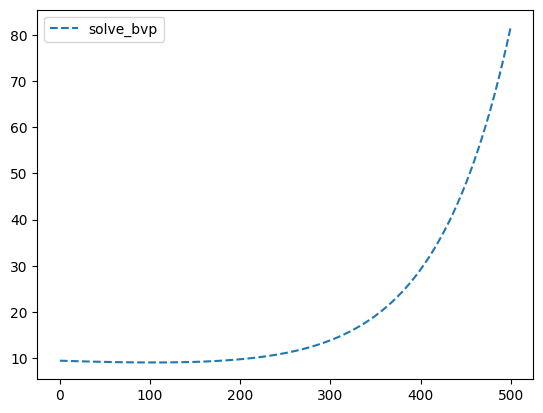

In [3]:
x_plot = np.linspace(0,L,1000)
y_plot = ss(x_plot)

y_prime = np.diff(y_plot)

fig, ax = plt.subplots(1,1)
ax.plot(x_plot, y_plot, linestyle='--', label='solve_bvp')
# ax.set_ylim(0, y_plot.max()*1.1);
# ax.plot(x_plot, ss(x_plot), label='analytical?')

# ax.set_ylim(0.1,0.3)
ax.legend()


[]

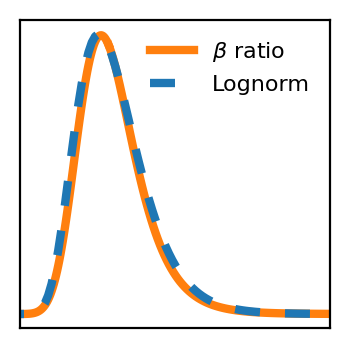

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import poch, factorial
from scipy.stats import lognorm

def g(x):
    res = 0
    for n in range(13):
        res += poch(26, n) * poch(-12, n) / poch(39, n) * x**n / factorial(n)

    return res*x**(12)*6e4

def h(x):
    res = 0
    for n in range(13):
        res += poch(26, n) * poch(-12, n) / poch(39, n) * x**(-n) / factorial(n)

    return res*x**(-14)*6e4

x_left = np.linspace(0,1,100)
x_right = np.linspace(1,3,100)
x_tot = np.linspace(0,3,100)

fig, axs = plt.subplots(1,1,figsize=(2,2), dpi=200)

ax = axs
c='tab:orange'
ax.plot(x_left, g(x_left), c=c, linewidth=3)
ax.plot(x_right, h(x_right), c=c, linewidth=3, label=r'$\beta$ ratio')

c = 'tab:blue'

ax.plot(x_tot, lognorm.pdf(x_tot, 0.30), linewidth=3, linestyle=(0,(3,3)), c=c,
        label='Lognorm')

ax.legend(frameon=False, fontsize=8)
# ax.set_xscale('log')
ax.set_xlim(0.2, 3)

ax.set_xticks([])
ax.set_yticks([])

# for k, v in ax.spines.items():
#     if k != 'bottom': v.set_visible(False)b

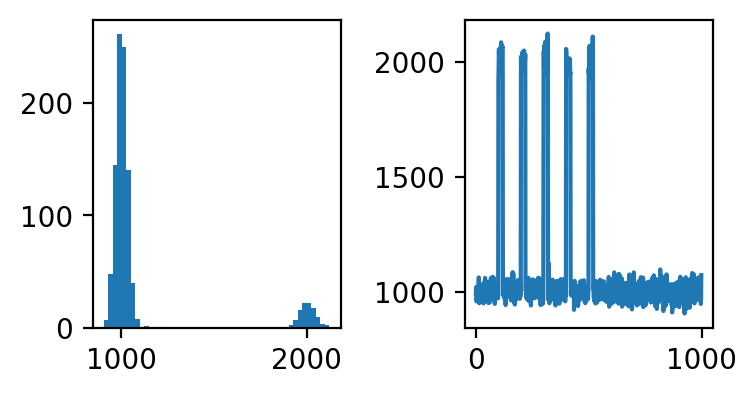

In [5]:
noise = 1000
signal = 1000

trace = np.random.poisson(noise, size=(1000))

for i in [100,200,300,400,500]:
    trace[i:i+20] += np.random.poisson(signal, size=(20))

fig, axs = plt.subplots(1,2,figsize=(4,2), dpi=200)
fig.subplots_adjust(wspace=0.5)
axs[0].hist(trace, bins=50)
axs[1].plot(trace)

In [6]:
def prune_trace(trace, iterations, sigma):
    
    pruned_trace = trace

    for _ in range(iterations):
        th = pruned_trace.mean() + pruned_trace.std() * sigma
        pruned_trace = pruned_trace[np.where(pruned_trace < th)]

    th = pruned_trace.mean() + pruned_trace.std() * sigma
    signal = trace[np.where(trace > th)]
    signal_t = np.where(trace > th)[0]

    return signal_t, signal



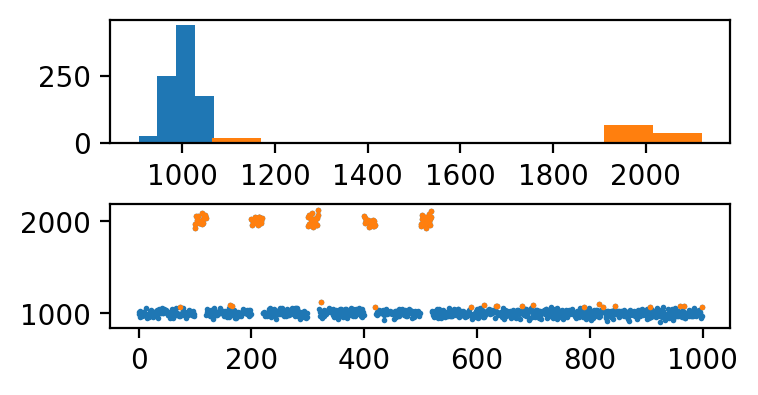

In [7]:
signal_t, signal = prune_trace(trace, 1, 2)

fig, axs = plt.subplots(2,1,figsize=(4,2), dpi=200)
fig.subplots_adjust(hspace=0.5)
axs[0].hist(trace, bins=30)
axs[0].hist(signal)
axs[1].scatter(range(len(trace)), trace, s=1)
axs[1].scatter(signal_t, signal, s=1)

In [8]:
def angles(X):

    if len(X.shape) > 2: X = X.reshape(X.shape[0], -1)
    
    angles = []

    for i in range(len(X)):
        for j in range(i+1,len(X)):
            cos = X[i]@X[j]/np.linalg.norm(X[i])/np.linalg.norm(X[j])
            angles.append(np.arccos(cos))

    return np.array(angles)/np.pi*180
        

def cosines(X):

    if len(X.shape) > 2: X = X.reshape(X.shape[0], -1)
    
    cosines = []

    for i in range(len(X)):
        for j in range(i+1,len(X)):
            cos = X[i]@X[j]/np.linalg.norm(X[i])/np.linalg.norm(X[j])
            cosines.append(cos)

    return cosines

X = np.random.rand(2,100)-0.5
X[:,0] = 1

angles(X)



array([93.18889362])

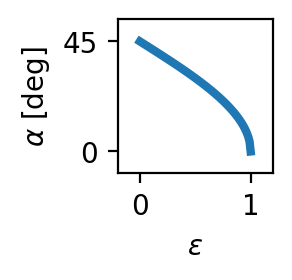

In [9]:
x = np.linspace(0,1,100)
y = 0.5*np.arccos(x)*180/np.pi


fig, ax = plt.subplots(1,1, figsize=(1,1), dpi=200)
ax.plot(x,y,linewidth=3)
ax.set_xlabel(r'$\epsilon$')
ax.set_ylabel(r'$\alpha$ [deg]')
ax.set_xmargin(0.2)
ax.set_ymargin(0.2)
ax.set_xticks([0,1])
ax.set_yticks([0,45])

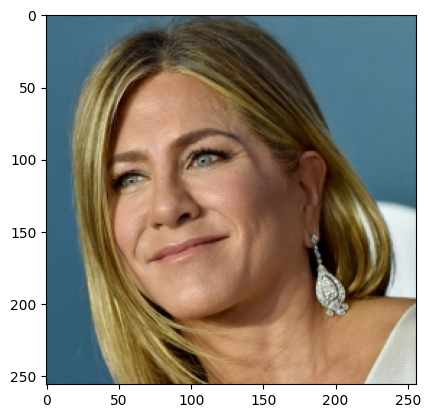

In [10]:
from PIL import Image

image = Image.open('jenanist.jpg')
ja = np.asarray(image).copy()
ja = ja / 255
plt.imshow(ja)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


[61.87336382 61.79376727 61.96963246 61.92194716 61.87310651 61.93217896]


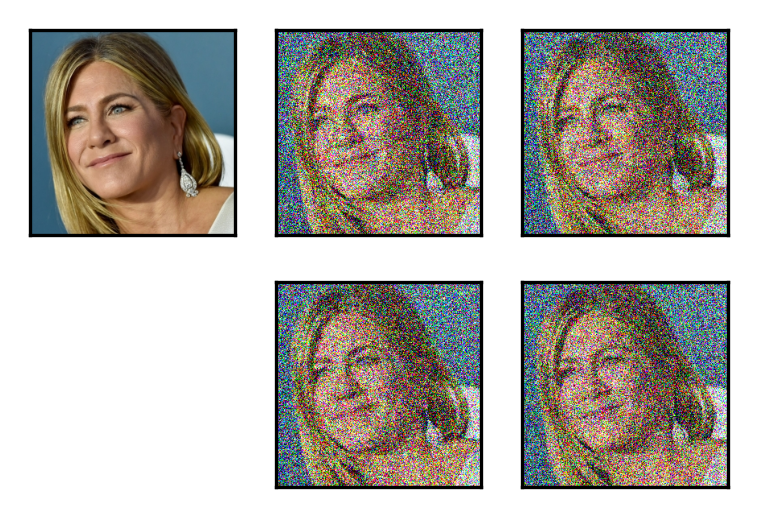

In [11]:
jas = []
for i in range(4):
    jas.append(ja + np.random.randn(*ja.shape) * 0.5)

jas = np.stack(jas, axis=0)

fig, axs = plt.subplots(2,3, figsize=(3,2), dpi=300)

axs[0,0].imshow(ja)
axs[1,0].remove()

for ax, j in zip(axs.T.flatten()[2:], jas):
    ax.imshow(j)

for ax in axs.flatten():
    ax.set_xticks([])
    ax.set_yticks([])


angle = angles(jas)
print(angle)

# print(angles(np.stack())

/tmp/ipykernel_1773424/2585315203.py:7: RuntimeWarning: invalid value encountered in arccos
  angles = np.arccos(cosines)/np.pi*180


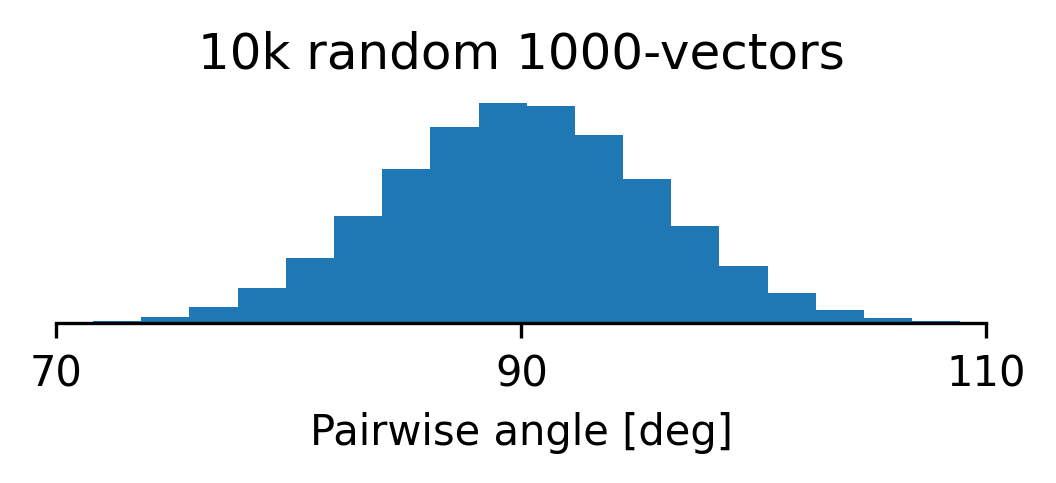

In [12]:
X = np.random.randn(10000,100)
# X[:,4] = 10

dot_products = X @ X.T
norms = np.sqrt(np.diag(dot_products))
cosines = dot_products / np.outer(norms, norms)
angles = np.arccos(cosines)/np.pi*180

# Self-orthogonality mask
mask = np.triu_indices(10000, 1)

ax = plt.figure(figsize=(4,1), dpi=300).add_subplot()
ax.hist(angles[mask], bins=30)
ax.set_xlim(70,110)
ax.set_xticks([70,90,110])
ax.set_yticks([])

ax.set_xlabel('Pairwise angle [deg]')
ax.set_title('10k random 1000-vectors')


for k, v in ax.spines.items():
    if k != 'bottom': v.set_visible(False)

In [13]:
def adjacent_values(vals, q1, q3):
    upper_adjacent_value = q3 + (q3 - q1) * 1.5
    upper_adjacent_value = np.clip(upper_adjacent_value, q3, vals[-1])

    lower_adjacent_value = q1 - (q3 - q1) * 1.5
    lower_adjacent_value = np.clip(lower_adjacent_value, vals[0], q1)
    return lower_adjacent_value, upper_adjacent_value

def custom_violin(ax, data, **kwargs):
    parts = ax.violinplot(data, showextrema=False, positions=range(len(data)), widths=0.8)
    
    for pc in parts['bodies']:
        pc.set_facecolor(kwargs.get('facecolor'))
        pc.set_edgecolor('black')
        pc.set_alpha(.5)

    quartile1, medians, quartile3 = np.percentile(data, [25, 50, 75], axis=1)
    whiskers = np.array([
        adjacent_values(sorted_array, q1, q3)
        for sorted_array, q1, q3 in zip(data, quartile1, quartile3)])
    whiskers_min, whiskers_max = whiskers[:, 0], whiskers[:, 1]

    inds = np.arange(0, len(medians))
    ax.scatter(inds, medians, marker='o', color='white', s=5, zorder=3)
    ax.vlines(inds, quartile1, quartile3, color='k', linestyle='-', lw=3)
    # ax.vlines(inds, whiskers_min, whiskers_max, color='k', linestyle='-', lw=1)

Text(0.5, 1.0, '$\\sigma=3$')

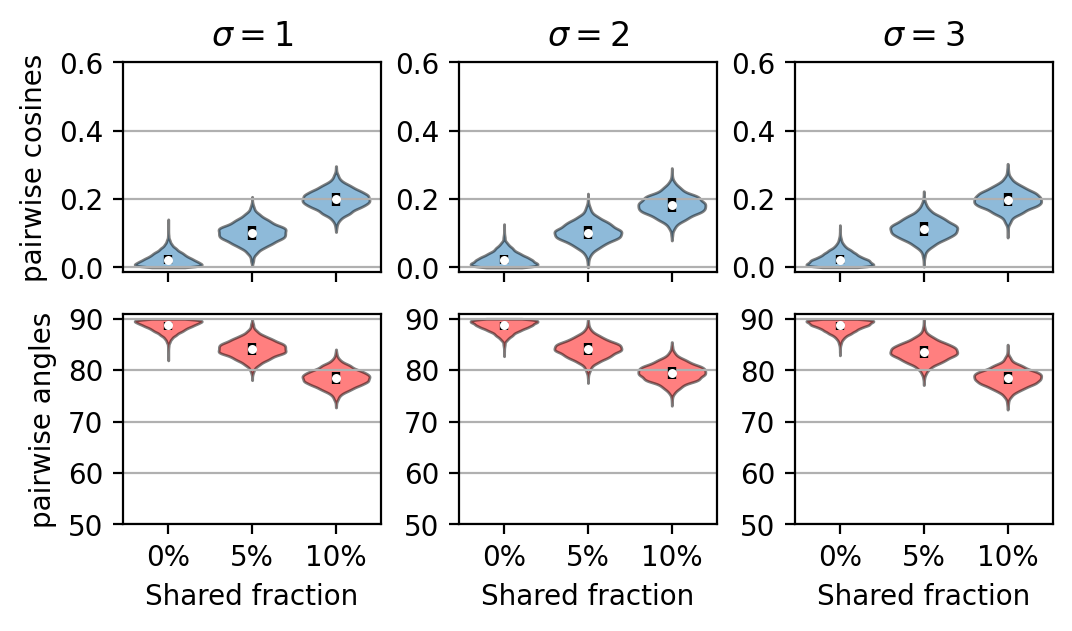

In [14]:
fig, axs = plt.subplots(2,3,figsize=(6,3), sharex=True, dpi=200)
fig.subplots_adjust(hspace=0.2, wspace=0.3)


for col, th in zip(axs.T,[2,4,6]):

    cosiness = []
    angless = []
    adjusted_activity = (((np.random.rand(100)>0.5)-0.5)*th).reshape(-1,1)

    for i in [0,100,200]:
        X = np.random.randn(100,1000)
        adjusted_activity = (((np.random.rand(100)>0.5)-0.5)*th).reshape(-1,1)
        adjusted_activity = np.tile(X[0,:i],(100, 1))
        X[:, :i] = adjusted_activity

        dot_products = X @ X.T
        norms = np.sqrt(np.diag(dot_products))

        coss = dot_products / np.outer(norms, norms)
        coss = np.abs(coss[np.triu_indices(100,1)])

        angles = np.arccos(coss)/np.pi*180
        
        cosiness.append(coss)
        angless.append(angles)

    custom_violin(col[0], cosiness)
    custom_violin(col[1], angless, facecolor='red')

for ax in axs[0]:
    ax.set_yticks((0,.2,.4,.6))
    ax.grid(axis='y')

for ax in axs[1]:
    ax.set_xticks([0,1,2],['0%','5%','10%'])
    ax.set_yticks((50,60,70,80,90))
    ax.grid(axis='y')
    ax.set_xlabel('Shared fraction')

axs[0,0].set_ylabel('pairwise cosines')
axs[1,0].set_ylabel('pairwise angles')
axs[0,0].set_title(r'$\sigma=1$')
axs[0,1].set_title(r'$\sigma=2$')
axs[0,2].set_title(r'$\sigma=3$')

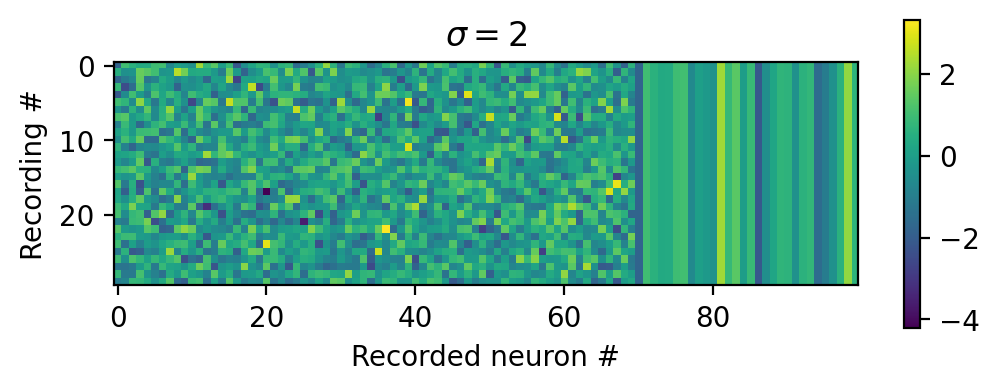

In [15]:
fig, ax = plt.subplots(1,1,figsize=(6,2), dpi=200)

i = 30

X = np.random.randn(30,100)
mask = np.where(X[0])
adjusted_activity = (((np.random.rand(30)>0.5)-0.5)*4).reshape(-1,1)
adjusted_activity = np.tile(X[0,:i],(30, 1))
X[:,-i:] = adjusted_activity
plt.imshow(X)

ax.set_title(r'$\sigma=2$')
ax.set_xlabel(r'Recorded neuron #')
ax.set_ylabel('Recording #')
plt.colorbar()

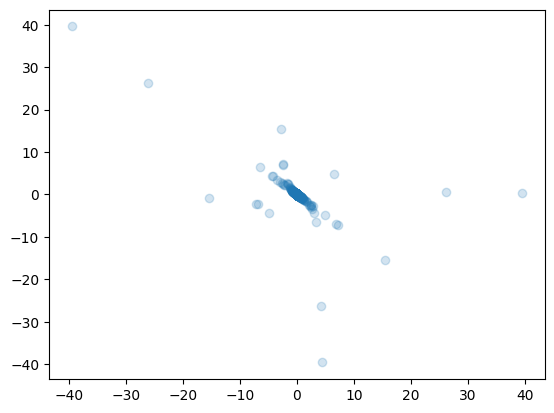

In [16]:
def f(x,k):
    return -k*x + (10-x)/x


dt = 1e-4
k = 0.7

xt = [0.5]

for _ in range(100000):
    xt.append(dt * f(xt[-1],k))

xt = np.array(xt)

deltas = xt[1:] - xt[:-1]
plt.scatter(deltas[:-1], deltas[1:], alpha=0.2)

In [18]:
import matplotlib as mpl
mpl.style.use('dark_background')

[]

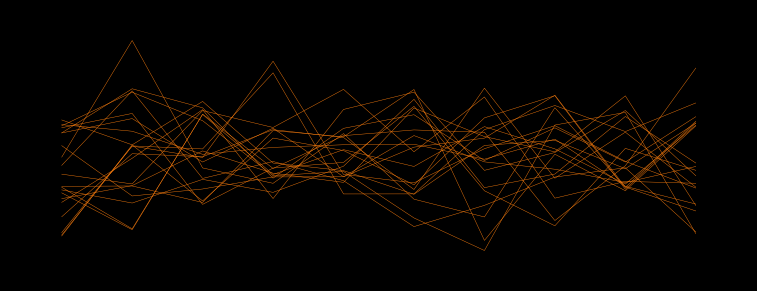

In [172]:
epochs = 10
neurons = 20

deltas = np.random.randn(neurons,epochs)
etas = np.random.randn(neurons,epochs)*0.

xs = [np.random.randn(neurons)]

for i in range(1,epochs):
    xs.append(xs[-1]*(1+etas[:,i])*0 + deltas[:,i])

xs = np.stack(xs, axis=1)
# xs = np.cumsum(deltas, axis=1)
# xs[:,0] = 0

fig, ax = plt.subplots(1,1, figsize=(3,1), dpi=300)

for x in xs:
    ax.plot(-x, c='tab:orange', alpha=1, linewidth=0.1)

for s in ax.spines.values(): s.set_visible(False)
ax.set_xticks([])
ax.set_yticks([])